# Forward sintético + ruido + misfit

Este notebook hace un ejemplo end-to-end con la implementación física nueva:
1. Lee `input.ctl`.
2. Construye el modelo con los valores medios de los 7 parámetros de inversión.
3. Aplica el mapeo elíptico físico y calcula $M_0$ total y $M_w$.
4. Ejecuta el forward con AXITRA.
5. Genera datos observados sintéticos agregando ruido gaussiano.
6. Compara señales limpias vs ruidosas y calcula el misfit.

In [1]:
from pathlib import Path
import sys
import numpy as np
import matplotlib.pyplot as plt

def find_project_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / 'kdellipspy').exists():
            return p
    raise FileNotFoundError('No se encontro PROJECT_ROOT con carpeta kdellipspy.')

PROJECT_ROOT = find_project_root(Path.cwd().resolve())
KIN_ROOT = PROJECT_ROOT / 'Kinematic_inversion'

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from kdellipspy.config_parser import ConfigParser
from kdellipspy.forward_model import AxitraForwardModel
from kdellipspy.inversion_na import MisfitCalculator
from kdellipspy.signal_utils import build_azi_times_array

ROOT = KIN_ROOT
INPUT_CTL = ROOT / 'input.ctl'
AXITRA_DIR = PROJECT_ROOT / 'kdellipspy' / 'AXITRA2024'
OUT_DIR = ROOT / 'output' / 'synthetic_forward_example_notebook'

if not INPUT_CTL.exists():
    raise FileNotFoundError(f'No se encontro input.ctl en {INPUT_CTL}')
if not AXITRA_DIR.exists():
    raise FileNotFoundError(f'No se encontro AXITRA2024 en {AXITRA_DIR}')

OUT_DIR.mkdir(parents=True, exist_ok=True)

print('PROJECT_ROOT:', PROJECT_ROOT)
print('ROOT      :', ROOT)
print('INPUT_CTL :', INPUT_CTL)
print('AXITRA_DIR:', AXITRA_DIR)
print('OUT_DIR   :', OUT_DIR)

PROJECT_ROOT: /home/alex/KDEllipsPy
ROOT      : /home/alex/KDEllipsPy/Kinematic_inversion
INPUT_CTL : /home/alex/KDEllipsPy/Kinematic_inversion/input.ctl
AXITRA_DIR: /home/alex/KDEllipsPy/kdellipspy/AXITRA2024
OUT_DIR   : /home/alex/KDEllipsPy/Kinematic_inversion/output/synthetic_forward_example_notebook


In [8]:
cfg = ConfigParser(str(INPUT_CTL))
station_names = [s.name for s in cfg.stations.stations]

midpoint_model = np.array([
    0.5 * (float(p.min_val) + float(p.max_val))
    for p in cfg.inversion_params.parameters
], dtype=float)

if midpoint_model.size != 7:
    raise ValueError(f'Se esperaban 7 parametros, pero hay {midpoint_model.size}.')

print('Evento         :', cfg.source_position.event_name)
print('N estaciones   :', len(station_names))
print('Modelo medio   :', np.array2string(midpoint_model, precision=4))

Evento         : Event Copiapo 2025 INTRAPLATE
N estaciones   : 10
Modelo medio   : [7.5 7.5 1.  0.5 0.5 2.  2. ]


In [9]:
fm = AxitraForwardModel(str(INPUT_CTL), axitra_dir=str(AXITRA_DIR))
geom = fm.build_geometry_with_ellipse_slip(midpoint_model)
m0_total, mw_total = fm.estimate_total_moment_and_mw(midpoint_model, geometry=geom)

ap = None
try:
    ap = fm.build_axitra(geom, latlon=False, freesurface=True)
    ap = fm.green(ap, quiet=True)
    time, sx, sy, sz = fm.conv(ap, geom, source_type=1, t0=float(cfg.ellipse.t0), quiet=True)
finally:
    if ap is not None:
        try:
            ap.clean()
        except Exception:
            pass

time = np.asarray(time, dtype=float)
clean = np.array([sx, sy, sz], dtype=float)
clean = np.transpose(clean, (1, 2, 0))
clean = np.transpose(clean, (0, 2, 1))

print('Shape clean:', clean.shape, '(nsta, ncomp, npts)')
print('t[0], t[-1], dt:', float(time[0]), float(time[-1]), float(time[1]-time[0]) if time.size > 1 else np.nan)
print(f'M0 total [N.m]: {m0_total:.6e}')
print(f'Mw total       : {mw_total:.4f}')

Shape clean: (10, 3, 512) (nsta, ncomp, npts)
t[0], t[-1], dt: 0.0 127.75 0.25
M0 total [N.m]: 1.838062e+19
Mw total       : 6.7762


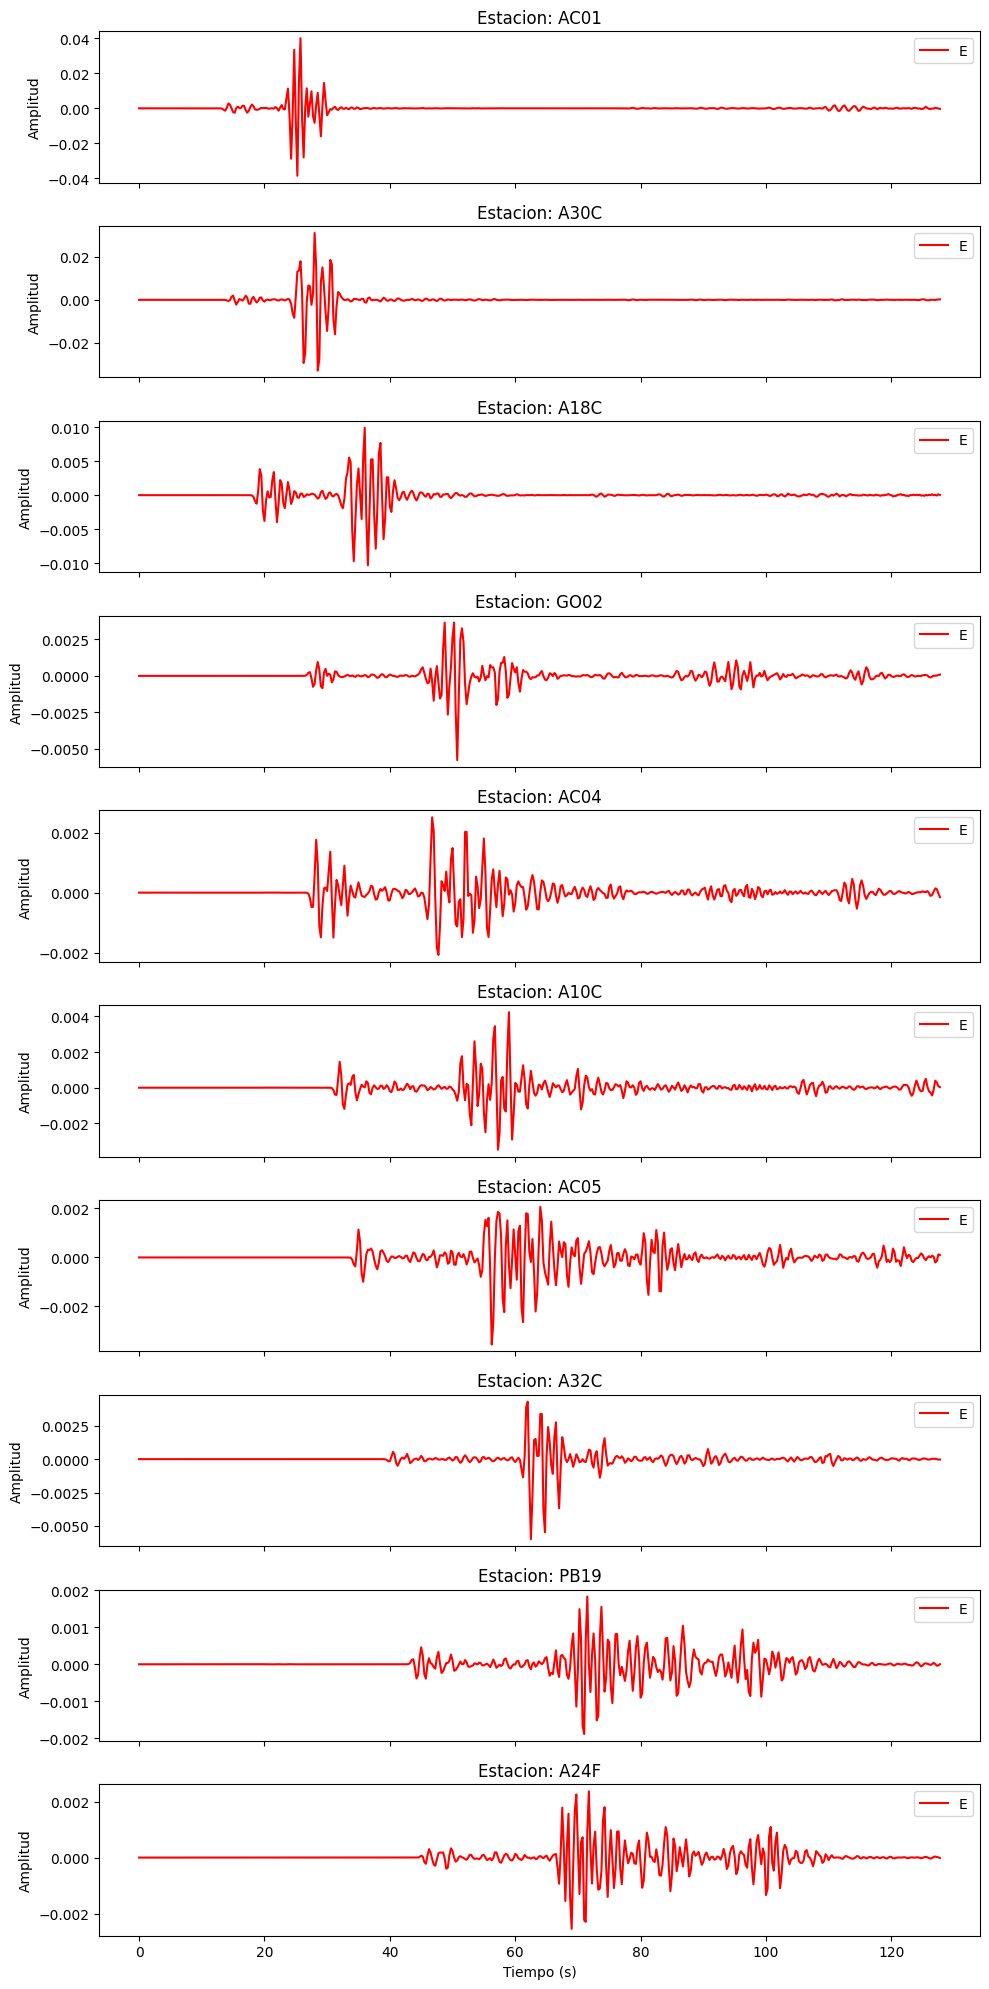

In [10]:
# Graficar las señales sintéticas
fig, axes = plt.subplots(len(station_names), 1, figsize=(10, 2 * len(station_names)), sharex=True)
if len(station_names) == 1:
    axes = [axes]
for i, (name, ax) in enumerate(zip(station_names, axes)):
    ax.plot(time, clean[i, 0], label='E', color='r')
    # ax.plot(time, clean[i, 1], label='N', color='g')
    # ax.plot(time, clean[i, 2], label='Z', color='b')
    ax.set_title(f'Estacion: {name}')
    ax.set_ylabel('Amplitud')
    ax.legend()
axes[-1].set_xlabel('Tiempo (s)')
plt.tight_layout()
plt.show()

In [12]:
NOISE_RATIO = 0.1
SEED = 20260420

rng = np.random.default_rng(SEED)
rms = float(np.sqrt(np.mean(clean ** 2)))
noise_std = max(rms * NOISE_RATIO, 1e-14)
observed_noisy = clean + noise_std * rng.standard_normal(clean.shape)

azi_times = build_azi_times_array(input_ctl_path=INPUT_CTL)
misfit_calc = MisfitCalculator(
    observed_waveforms=observed_noisy,
    time_array=time,
    azi_times_array=azi_times,
    time_window_s=20.0,
)
misfit = float(misfit_calc.l2_misfit(clean))
diag_text = misfit_calc.diagnostics_summary(clean, max_stations=3)

print(f'Noise ratio        : {NOISE_RATIO:.4f}')
print(f'Noise std global   : {noise_std:.6e}')
print(f'Misfit (clean/noisy): {misfit:.6e}')
print('\n--- Diagnostics ---')
print(diag_text)

Noise ratio        : 0.1000
Noise std global   : 1.250688e-04
Misfit (clean/noisy): 1.807646e-03

--- Diagnostics ---
[MISFIT DIAG] rms_global(obs)=1.258e-03 rms_global(syn)=1.251e-03 syn/obs=9.946e-01
[MISFIT DIAG] sta=01 P(R): obs=1.059e-02 syn=1.060e-02 | P(Z): obs=5.747e-03 syn=5.738e-03 | S(T): obs=1.590e-03 syn=1.591e-03
[MISFIT DIAG] sta=02 P(R): obs=6.735e-03 syn=6.720e-03 | P(Z): obs=3.811e-03 syn=3.835e-03 | S(T): obs=6.566e-03 syn=6.529e-03
[MISFIT DIAG] sta=03 P(R): obs=2.080e-03 syn=2.093e-03 | P(Z): obs=1.747e-03 syn=1.751e-03 | S(T): obs=2.861e-03 syn=2.863e-03
[MISFIT DIAG] window_energy(obs)=2.176e-02 window_energy(syn)=2.171e-02 syn/obs=9.978e-01


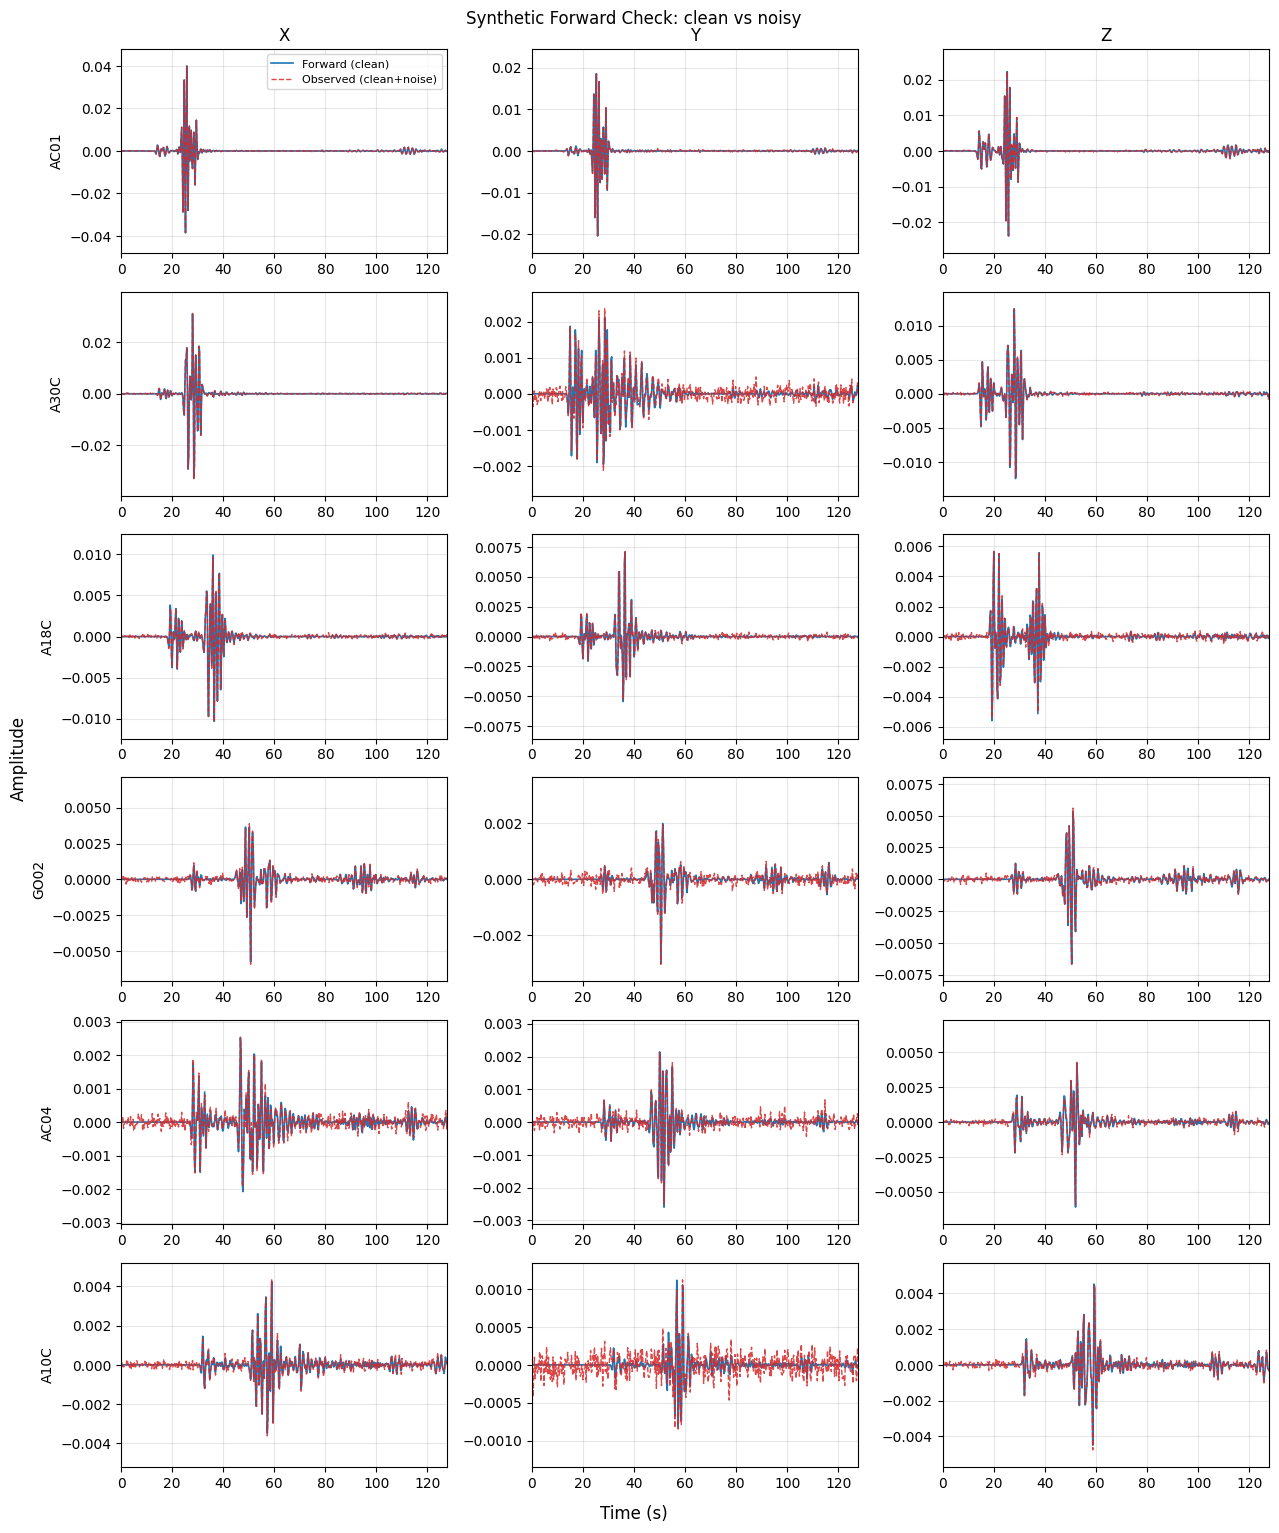

Figura guardada en: /home/alex/KDEllipsPy/Kinematic_inversion/output/synthetic_forward_example_notebook/synthetic_forward_comparison.png


In [13]:
MAX_STATIONS_PLOT = 6
nsta = clean.shape[0]
nsel = min(MAX_STATIONS_PLOT, nsta)

comp_names = ['X', 'Y', 'Z']
fig, axes = plt.subplots(nsel, 3, figsize=(13, 2.6 * nsel), squeeze=False)

for i in range(nsel):
    sta_name = station_names[i] if i < len(station_names) else f'STA_{i+1:02d}'
    for icomp, comp_name in enumerate(comp_names):
        ax = axes[i][icomp]
        y_clean = clean[i, icomp, :]
        y_noisy = observed_noisy[i, icomp, :]
        peak = float(max(np.max(np.abs(y_clean)), np.max(np.abs(y_noisy)), 1e-12))

        ax.plot(time, y_clean, color='tab:blue', lw=1.2, label='Forward (clean)')
        ax.plot(time, y_noisy, color='tab:red',linestyle='--', lw=1.0, alpha=0.85, label='Observed (clean+noise)')
        ax.set_xlim(float(time[0]), float(time[-1]))
        ax.set_ylim(-1.2 * peak, 1.2 * peak)
        ax.grid(True, alpha=0.3)

        if i == 0:
            ax.set_title(comp_name)
        if icomp == 0:
            ax.set_ylabel(sta_name)
        if i == 0 and icomp == 0:
            ax.legend(loc='upper right', fontsize=8)

fig.suptitle('Synthetic Forward Check: clean vs noisy')
fig.supxlabel('Time (s)')
fig.supylabel('Amplitude')
fig.tight_layout()

fig_path = OUT_DIR / 'synthetic_forward_comparison.png'
fig.savefig(fig_path, dpi=180)
plt.show()

print('Figura guardada en:', fig_path)

# Cálculo de Misfit (Normalized L2)

El **MisfitCalculator** implementa un misfit normalizado de mínimos cuadrados con las siguientes características:

## Estructura del Misfit

**Ventanas de tiempo sísmico:**
- **Ventana P**: Desde `tP` a `tP + time_window_s` (por defecto 20s)
  - Componentes: **Radial** (R = X·cos(az) + Y·sin(az)) + **Vertical** (Z)
- **Ventana S**: Desde `tS` a `tS + time_window_s`
  - Componentes: **Transversal** (T = Y·cos(az) - X·sin(az))

**Rotación de componentes (según azimut de cada estación):**
- X (Norte) e Y (Este) → Radial/Transversal usando azimut

## Fórmula

$$\text{misfit} = \frac{\sum \text{residuales}^2}{\sum \text{energía observada}^2}$$

Donde:
- Numerador: $\sum (obs - syn)^2$ en ventanas P (R,Z) y S (T)
- Denominador: $\sum obs^2$ en las mismas ventanas

**Interpretación:**
- misfit = 0 → Ajuste perfecto
- misfit → 1 → Amplitud sintética similar a observada pero con fase diferente
- misfit >> 1 → Sintético muy diferente del observado


In [16]:
# Calcular misfit normalizado L2 (método de inversión sísmica)
misfit_l2 = float(misfit_calc.l2_misfit(clean))

print('='*70)
print('NORMALIZED L2 MISFIT (Seismic Inversion Method)')
print('='*70)
print(f'\nMisfit (Clean vs Observed+Noise): {misfit_l2:.6e}')
print(f'\nInterpretación:')
print(f'  - misfit ≈ 0   → Ajuste perfecto')
print(f'  - misfit ≈ 1   → Amplitudes similares, fases diferentes')
print(f'  - misfit >> 1  → Sintéticos muy diferentes')

# Diagnostics detallados (incluye ventanas P y S)
print(f'\n--- Diagnostics (Ventanas P y S) ---')
diag = misfit_calc.diagnostics_summary(clean, max_stations=6)
print(diag)

# Análisis de residuales
residuals = observed_noisy - clean
residuals_rms_global = np.sqrt(np.mean(residuals ** 2))
residuals_rms_per_sta = np.sqrt(np.mean(residuals ** 2, axis=(1, 2)))

print(f'\n--- Análisis de Residuales ---')
print(f'RMS residual global: {residuals_rms_global:.6e}')
print(f'Noise STD aplicado  : {noise_std:.6e}')
print(f'Ratio residual/noise: {residuals_rms_global / noise_std:.3f}')
print(f'\nRMS por estación:')
for name, rms in zip(station_names, residuals_rms_per_sta):
    print(f'  {name:8s}: {rms:.6e}')


NORMALIZED L2 MISFIT (Seismic Inversion Method)

Misfit (Clean vs Observed+Noise): 1.807646e-03

Interpretación:
  - misfit ≈ 0   → Ajuste perfecto
  - misfit ≈ 1   → Amplitudes similares, fases diferentes
  - misfit >> 1  → Sintéticos muy diferentes

--- Diagnostics (Ventanas P y S) ---
[MISFIT DIAG] rms_global(obs)=1.258e-03 rms_global(syn)=1.251e-03 syn/obs=9.946e-01
[MISFIT DIAG] sta=01 P(R): obs=1.059e-02 syn=1.060e-02 | P(Z): obs=5.747e-03 syn=5.738e-03 | S(T): obs=1.590e-03 syn=1.591e-03
[MISFIT DIAG] sta=02 P(R): obs=6.735e-03 syn=6.720e-03 | P(Z): obs=3.811e-03 syn=3.835e-03 | S(T): obs=6.566e-03 syn=6.529e-03
[MISFIT DIAG] sta=03 P(R): obs=2.080e-03 syn=2.093e-03 | P(Z): obs=1.747e-03 syn=1.751e-03 | S(T): obs=2.861e-03 syn=2.863e-03
[MISFIT DIAG] sta=04 P(R): obs=3.256e-04 syn=2.767e-04 | P(Z): obs=3.386e-04 syn=3.204e-04 | S(T): obs=4.967e-04 syn=4.692e-04
[MISFIT DIAG] sta=05 P(R): obs=5.157e-04 syn=4.815e-04 | P(Z): obs=5.415e-04 syn=5.423e-04 | S(T): obs=6.106e-04 syn=6.

In [17]:
# Verificación: Calcular misfit manualmente y comparar con MisfitCalculator
# Esto valida que la implementación funciona correctamente

print('='*70)
print('VALIDACIÓN DE IMPLEMENTACIÓN DEL MISFIT')
print('='*70)

# 1. Misfit simple (sin rotación, todas las componentes)
residuals = observed_noisy - clean
misfit_simple_l2 = np.sum(residuals ** 2) / np.sum(observed_noisy ** 2)
print(f'\n1. Simple L2 (sin rotación, todas componentes):')
print(f'   misfit = Σ(residuales)² / Σ(obs)² = {misfit_simple_l2:.6e}')

# 2. Misfit calculado por MisfitCalculator (con ventanas P/S y rotación)
misfit_with_windows = float(misfit_calc.l2_misfit(clean))
print(f'\n2. L2 con ventanas P/S + rotación (MisfitCalculator):')
print(f'   misfit = {misfit_with_windows:.6e}')
print(f'   Razón (con_ventanas / sin_ventanas): {misfit_with_windows / misfit_simple_l2:.3f}')

# 3. Misfit con caso ideal (sintético = observado)
misfit_perfect = float(misfit_calc.l2_misfit(observed_noisy))
print(f'\n3. Caso ideal (sínt = obs):')
print(f'   misfit = {misfit_perfect:.6e} (debería ser ~0)')

# 4. Análisis de componentes sin rotación
misfit_x = np.sum((residuals[:, 0, :]) ** 2) / np.sum(observed_noisy[:, 0, :] ** 2)
misfit_y = np.sum((residuals[:, 1, :]) ** 2) / np.sum(observed_noisy[:, 1, :] ** 2)
misfit_z = np.sum((residuals[:, 2, :]) ** 2) / np.sum(observed_noisy[:, 2, :] ** 2)
print(f'\n4. Misfit por componente (simple, sin rotación):')
print(f'   X (North): {misfit_x:.6e}')
print(f'   Y (East) : {misfit_y:.6e}')
print(f'   Z (Up)   : {misfit_z:.6e}')

print(f'\n✓ Validación completada')


VALIDACIÓN DE IMPLEMENTACIÓN DEL MISFIT

1. Simple L2 (sin rotación, todas componentes):
   misfit = Σ(residuales)² / Σ(obs)² = 9.980631e-03

2. L2 con ventanas P/S + rotación (MisfitCalculator):
   misfit = 1.807646e-03
   Razón (con_ventanas / sin_ventanas): 0.181

3. Caso ideal (sínt = obs):
   misfit = 0.000000e+00 (debería ser ~0)

4. Misfit por componente (simple, sin rotación):
   X (North): 4.936925e-03
   Y (East) : 3.125380e-02
   Z (Up)   : 1.484005e-02

✓ Validación completada



SENSIBILIDAD A RUIDO
  Noise ratio: 0.0% → misfit = 0.000000e+00
  Noise ratio: 5.0% → misfit = 2.485159e-03
  Noise ratio: 10.0% → misfit = 9.744492e-03
  Noise ratio: 20.0% → misfit = 3.845905e-02
  Noise ratio: 50.0% → misfit = 1.995015e-01
  Noise ratio: 100.0% → misfit = 4.964356e-01


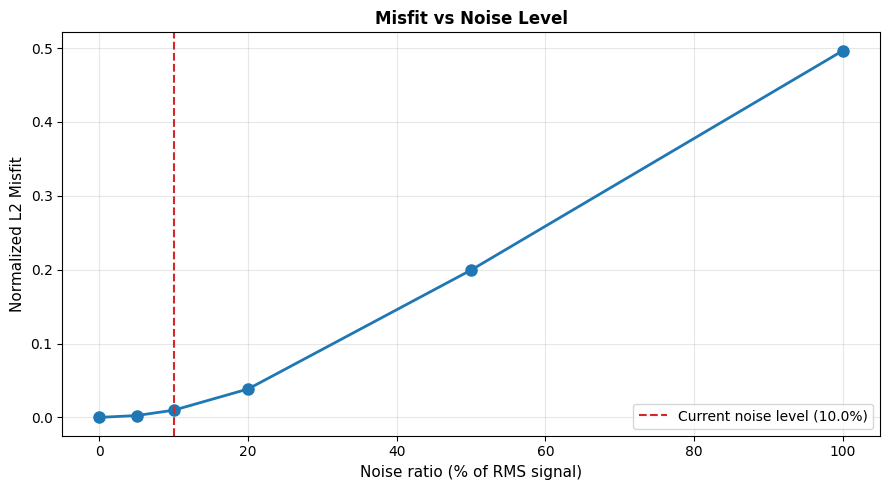


Figura guardada en: /home/alex/KDEllipsPy/Kinematic_inversion/output/synthetic_forward_example_notebook/misfit_sensitivity_to_noise.png


In [18]:
# Sensibilidad del misfit a diferentes niveles de ruido
print('\n' + '='*70)
print('SENSIBILIDAD A RUIDO')
print('='*70)

noise_ratios = np.array([0.0, 0.05, 0.1, 0.2, 0.5, 1.0])
misfits_noise = []

rms_clean = np.sqrt(np.mean(clean ** 2))

for noise_ratio in noise_ratios:
    noise_std_test = rms_clean * noise_ratio
    obs_test = clean + noise_std_test * rng.standard_normal(clean.shape)
    misfit_test = np.sum((obs_test - clean) ** 2) / np.sum(obs_test ** 2)
    misfits_noise.append(misfit_test)
    print(f'  Noise ratio: {noise_ratio:.1%} → misfit = {misfit_test:.6e}')

# Graficar sensibilidad
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(noise_ratios * 100, misfits_noise, 'o-', markersize=8, linewidth=2, color='tab:blue')
ax.axvline(NOISE_RATIO * 100, color='tab:red', linestyle='--', linewidth=1.5, 
           label=f'Current noise level ({NOISE_RATIO:.1%})')
ax.set_xlabel('Noise ratio (% of RMS signal)', fontsize=11)
ax.set_ylabel('Normalized L2 Misfit', fontsize=11)
ax.set_title('Misfit vs Noise Level', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend()
fig.tight_layout()

fig_path = OUT_DIR / 'misfit_sensitivity_to_noise.png'
fig.savefig(fig_path, dpi=180)
plt.show()

print(f'\nFigura guardada en: {fig_path}')


## Resumen: Cómo Funciona el Misfit

### En el Contexto de Inversión (NA = Neighborhood Algorithm)

El **misfit normalizado L2** es la función objetivo que se minimiza durante la inversión:

$$\text{objetivo} = \min_{\mathbf{m}} \left[ \frac{\sum_{ventanas} (d_{obs} - d_{syn}(\mathbf{m}))^2}{\sum_{ventanas} d_{obs}^2} \right]$$

**Donde:**
- $\mathbf{m}$ = vector de 7 parámetros [a₁, a₂, θ, n_p, t_p, d_max, v_r]
- $d_{obs}$ = datos observados (con ruido)
- $d_{syn}(\mathbf{m})$ = datos sintéticos (predicho por el modelo)
- ventanas = P (Radial+Vertical) y S (Transversal)

### Características Clave

1. **Normalización**: El misfit es dimensionless (entre 0 e ∞)
   - Permite comparar diferentes eventos/estaciones
   
2. **Ventanas sísmicas**: Solo usa P y S waves
   - Ignora ruido de coda
   - Mejora relación señal/ruido

3. **Rotación a componentes sísmicas**: N,E → Radial, Transversal
   - Considera azimut de cada estación
   - Detecta mejor llegadas de ondas

4. **Robustez**: Normalizado por energía observada
   - Insensible a escala de amplitudes
   - Penaliza principalmente errores de forma y timing
